In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


mob_df = pd.read_csv("../data/yjmob100k-dataset1.csv.gz")
grid_df = pd.read_csv("../data/cell_POIcat.csv.gz")
poi_map = pd.read_csv("../data/POI_datacategories.csv", header=None)

print(f"Mobility data shape: {mob_df.shape}")
print(f"Grid data shape: {grid_df.shape}")
print(f"\nMobility columns: {mob_df.columns.tolist()}")
print(f"\nFirst few rows:\n{mob_df.head()}")

ModuleNotFoundError: No module named 'exportgraphics'

C:\Users\moham\AppData\Local\Temp\ipykernel_23832\2237432001.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  movement_by_time = mob_df.groupby('timeslot').apply(


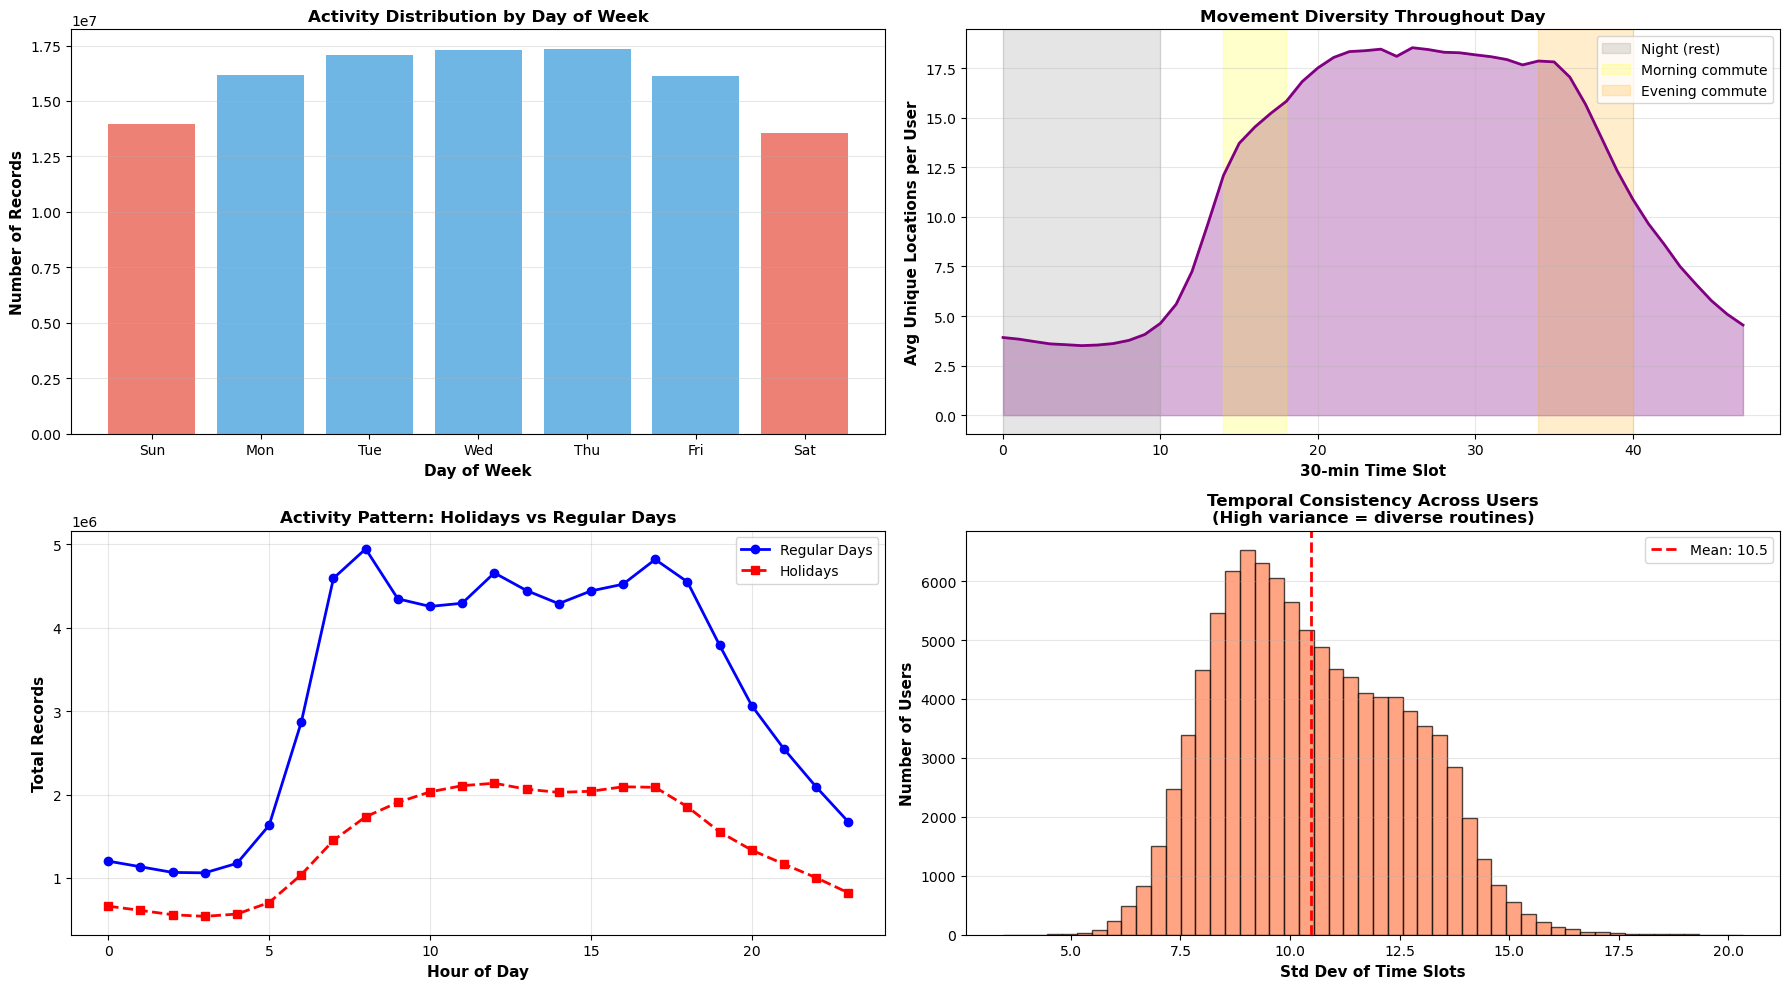

In [14]:
# Temporal Features Validation, we need to check:   
# 1. Day of week patterns (validates is_weekend feature)
# 2. Intra-day movement pattern (For the activity periods)
# 3. Holiday effect check (validates need for holiday feature)
# 4. Temporal variance by user (validates need for user-level temporal features)    

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1a: Day of week patterns (validates is_weekend feature)
mob_df['day_of_week'] = mob_df['d'] % 7
dow_activity = mob_df.groupby('day_of_week').size()

dow_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
colors = ['#e74c3c' if i in [0, 6] else '#3498db' for i in range(7)]
axes[0, 0].bar(range(7), dow_activity.values, color=colors, alpha=0.7)
axes[0, 0].set_xlabel('Day of Week', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Number of Records', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Activity Distribution by Day of Week', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(dow_labels, rotation=0)
axes[0, 0].grid(alpha=0.3, axis='y')


# 1b: Intra-day movement pattern (For the activity periods)
mob_df['timeslot'] = mob_df['t']
mob_df['hour'] = mob_df['t'] // 2
hourly_activity = mob_df.groupby('hour').size()

# Count unique locations per user per timeslot
movement_by_time = mob_df.groupby('timeslot').apply(
    lambda x: x.groupby('uid')[['x', 'y']].apply(lambda g: len(g.drop_duplicates()))
).reset_index()
movement_by_time.columns = ['timeslot', 'uid', 'unique_locs']
avg_movement = movement_by_time.groupby('timeslot')['unique_locs'].mean()

axes[0, 1].plot(avg_movement.index, avg_movement.values, linewidth=2, color='purple')
axes[0, 1].fill_between(avg_movement.index, avg_movement.values, alpha=0.3, color='purple')
axes[0, 1].set_xlabel('30-min Time Slot', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Avg Unique Locations per User', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Movement Diversity Throughout Day', 
                     fontsize=12, fontweight='bold')
axes[0, 1].axvspan(0, 10, alpha=0.2, color='gray', label='Night (rest)')
axes[0, 1].axvspan(14, 18, alpha=0.2, color='yellow', label='Morning commute')
axes[0, 1].axvspan(34, 40, alpha=0.2, color='orange', label='Evening commute')
axes[0, 1].legend(loc = 'upper right')
axes[0, 1].grid(alpha=0.3)

# 1c: Holiday effect check 
holiday_list = [0, 1, 6, 7, 8, 13, 14, 20, 21, 27, 28, 29, 34, 35, 37, 41, 42, 
                48, 49, 50, 55, 56, 62, 63, 69, 70] # Example holiday days
mob_df['is_holiday'] = mob_df['d'].isin(holiday_list).astype(int)
holiday_comparison = mob_df.groupby(['is_holiday', 'hour']).size().unstack(fill_value=0)

axes[1, 0].plot(holiday_comparison.columns, holiday_comparison.loc[0], 
                'b-', linewidth=2, label='Regular Days', marker='o')
axes[1, 0].plot(holiday_comparison.columns, holiday_comparison.loc[1], 
                'r--', linewidth=2, label='Holidays', marker='s')
axes[1, 0].set_xlabel('Hour of Day', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Total Records', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Activity Pattern: Holidays vs Regular Days', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 1d: Temporal variance by user 
user_variance = mob_df.groupby('uid')['t'].agg(['std', 'count']).reset_index()
user_variance = user_variance[user_variance['count'] > 50]  # Only consider users with >50 records for reliability

axes[1, 1].hist(user_variance['std'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Std Dev of Time Slots', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Users', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Temporal Consistency Across Users\n(High variance = diverse routines)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axvline(user_variance['std'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {user_variance["std"].mean():.1f}')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/temporal_validation.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_23832\1609328941.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_locs = mob_df.groupby('uid').apply(


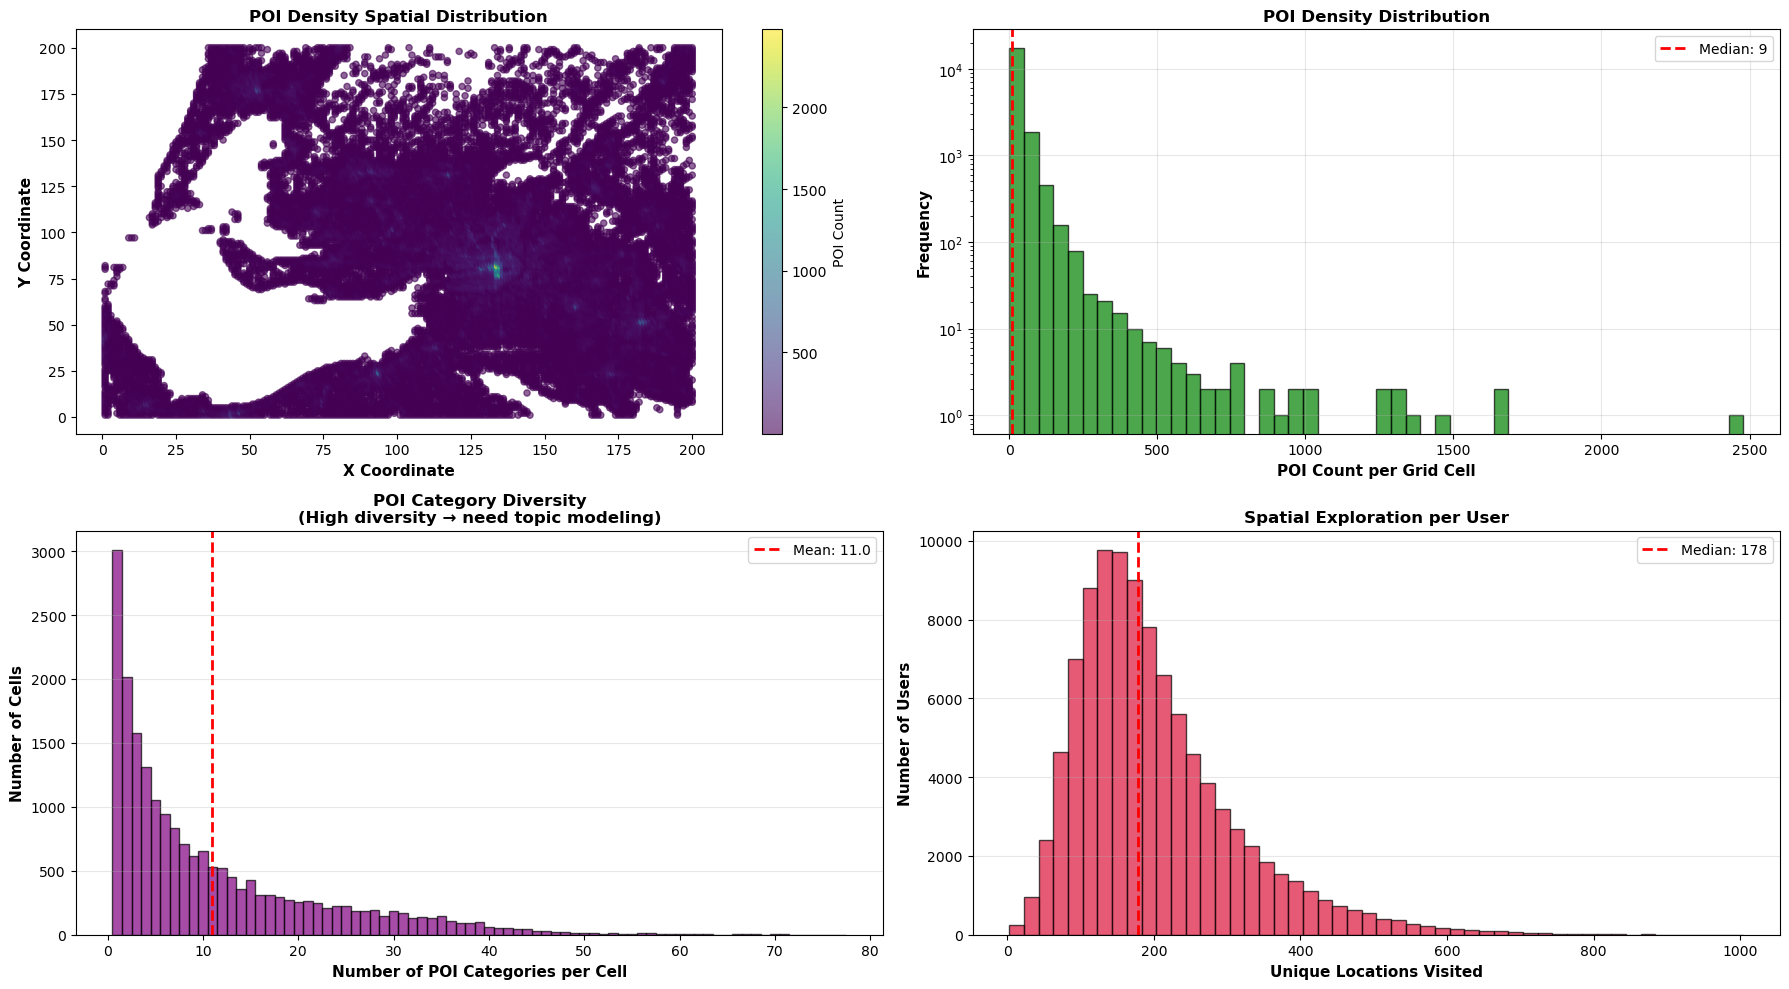

In [15]:
# For Validation of spatial features, we need to check:
# 1. Spatial distribution of POI density (validates need for spatial features)
# 2. Distribution of POI density (validates log transformation need)
# 3. Diversity of POI categories per cell (validates need for LDA/topic modeling)
# 4. Number of unique locations visited per user (validates need for exploration features)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 2a: Spatial distribution
grid_poi_density = grid_df.groupby(['x', 'y'])['POI_count'].sum().reset_index()

scatter = axes[0, 0].scatter(grid_poi_density['x'], grid_poi_density['y'], 
                             c=grid_poi_density['POI_count'], cmap='viridis', 
                             s=20, alpha=0.6)
axes[0, 0].set_xlabel('X Coordinate', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Y Coordinate', fontsize=11, fontweight='bold')
axes[0, 0].set_title('POI Density Spatial Distribution', 
                     fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0], label='POI Count')

# 2b: POI density distribution (validates log transformation need)
axes[0, 1].hist(grid_poi_density['POI_count'], bins=50, color='green', 
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('POI Count per Grid Cell', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('POI Density Distribution', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].axvline(grid_poi_density['POI_count'].median(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Median: {grid_poi_density["POI_count"].median():.0f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 2c: POI category diversity (Need for LDA/topic modeling)
poi_diversity = grid_df.groupby(['x', 'y'])['POIcategory'].nunique().reset_index()
poi_diversity.columns = ['x', 'y', 'num_categories']

axes[1, 0].hist(poi_diversity['num_categories'], bins=range(1, poi_diversity['num_categories'].max()+2), 
                color='purple', edgecolor='black', alpha=0.7, align='left')
axes[1, 0].set_xlabel('Number of POI Categories per Cell', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Cells', fontsize=11, fontweight='bold')
axes[1, 0].set_title('POI Category Diversity\n(High diversity → need topic modeling)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].axvline(poi_diversity['num_categories'].mean(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Mean: {poi_diversity["num_categories"].mean():.1f}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')


# 2d: Number of unique locations per user 
unique_locs = mob_df.groupby('uid').apply(
    lambda x: len(x[['x', 'y']].drop_duplicates())
).reset_index(name='unique_locations')

axes[1, 1].hist(unique_locs['unique_locations'], bins=50, color='crimson', 
                edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Unique Locations Visited', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Users', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Spatial Exploration per User', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axvline(unique_locs['unique_locations'].median(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Median: {unique_locs["unique_locations"].median():.0f}')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/spatial_validation.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_23832\2573412212.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  night_stability = night_records.groupby('uid').apply(
C:\Users\moham\AppData\Local\Temp\ipykernel_23832\2573412212.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_daily_locs = mob_df.groupby(['uid', 'd']).apply(


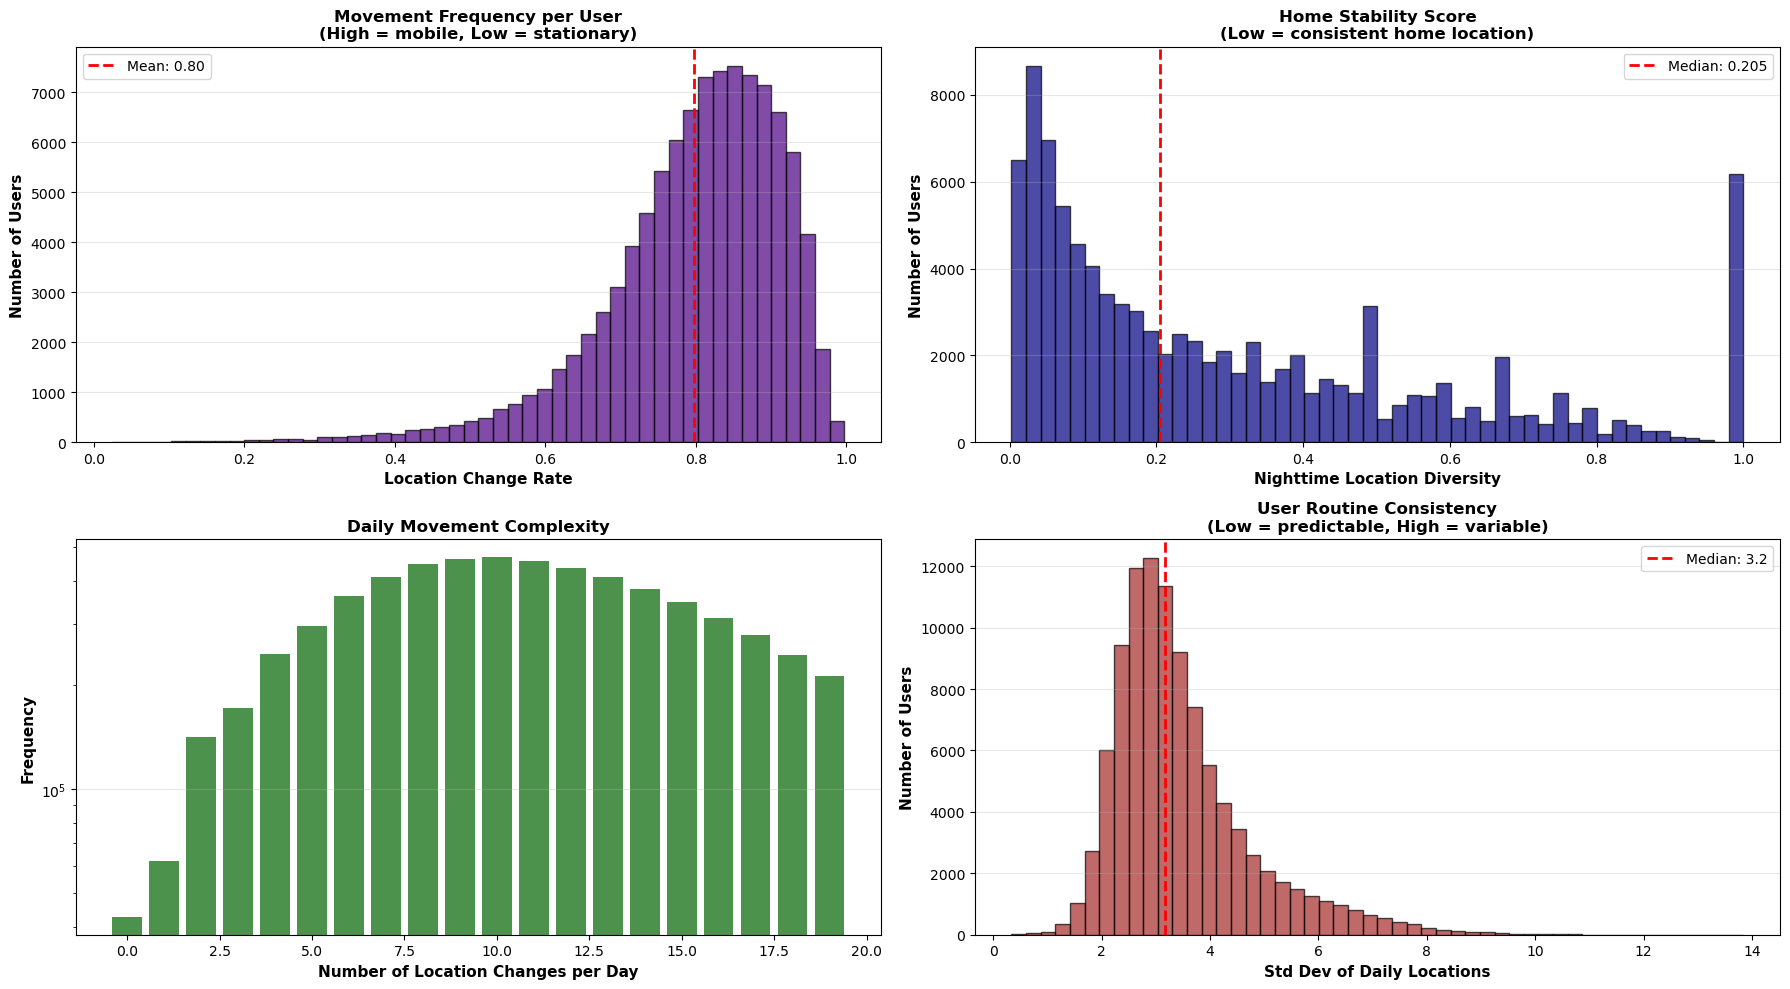

In [16]:
# For validation of behavioral features, we need to check:
# 1. Sequential location changes (validates state transition features)
# 2. Return-to-home patterns (validates motif detection)
# 3. Daily trip complexity (validates motif classification)
# 4. User consistency over time (validates person type features)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 3a: Sequential location changes (validates state transition features)
mob_df_sorted = mob_df.sort_values(['uid', 'd', 't'])
mob_df_sorted['loc_id'] = mob_df_sorted['x'].astype(str) + "_" + mob_df_sorted['y'].astype(str)
mob_df_sorted['loc_changed'] = (
    mob_df_sorted.groupby('uid')['loc_id'].shift() != mob_df_sorted['loc_id']
).astype(int)

change_rate = mob_df_sorted.groupby('uid')['loc_changed'].mean().reset_index()

axes[0, 0].hist(change_rate['loc_changed'], bins=50, color='indigo', 
                edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Location Change Rate', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Number of Users', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Movement Frequency per User\n(High = mobile, Low = stationary)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].axvline(change_rate['loc_changed'].mean(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Mean: {change_rate["loc_changed"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

# 3b: Return-to-home patterns (validates motif detection)
night_records = mob_df[mob_df['t'] < 12]  # Before 6am
night_stability = night_records.groupby('uid').apply(
    lambda x: len(x[['x', 'y']].drop_duplicates()) / len(x) if len(x) > 0 else np.nan
).reset_index(name='night_diversity')

axes[0, 1].hist(night_stability['night_diversity'].dropna(), bins=50, 
                color='navy', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Nighttime Location Diversity', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Number of Users', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Home Stability Score\n(Low = consistent home location)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].axvline(night_stability['night_diversity'].median(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Median: {night_stability["night_diversity"].median():.3f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

# 3c: Daily trip complexity
daily_transitions = mob_df_sorted.groupby(['uid', 'd'])['loc_changed'].sum().reset_index()
transitions_dist = daily_transitions.groupby('loc_changed').size()

axes[1, 0].bar(transitions_dist.index[:20], transitions_dist.values[:20], 
               color='darkgreen', alpha=0.7)
axes[1, 0].set_xlabel('Number of Location Changes per Day', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Daily Movement Complexity', 
                     fontsize=12, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(alpha=0.3, axis='y')

# 3d: User consistency over time (validates person type features)
user_daily_locs = mob_df.groupby(['uid', 'd']).apply(
    lambda x: len(x[['x', 'y']].drop_duplicates())
).reset_index(name='daily_locs')
user_consistency = user_daily_locs.groupby('uid')['daily_locs'].std().reset_index()

axes[1, 1].hist(user_consistency['daily_locs'].dropna(), bins=50, 
                color='brown', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Std Dev of Daily Locations', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Users', fontsize=11, fontweight='bold')
axes[1, 1].set_title('User Routine Consistency\n(Low = predictable, High = variable)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axvline(user_consistency['daily_locs'].median(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Median: {user_consistency["daily_locs"].median():.1f}')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')


plt.tight_layout()
plt.savefig('../figures/behavioral_validation.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()
